Mounted at /content/drive


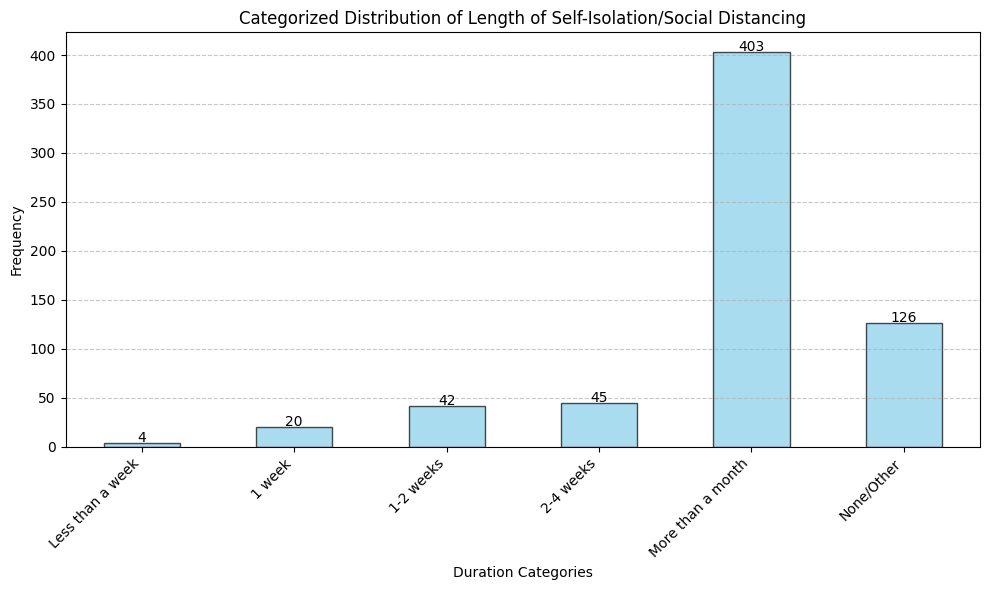

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')


# Load the file (replace 'file_path' with your actual file path if needed)
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Function to categorize responses in the "B2" column
def categorize_duration(value):
    value = str(value).lower()
    if "day" in value or "week" in value or "month" in value:
        if "less" in value or "1 day" in value or "a day" in value:
            return "Less than a week"
        elif "1 week" in value or "a week" in value:
            return "1 week"
        elif "2 weeks" in value or "a couple" in value:
            return "1-2 weeks"
        elif "3 weeks" in value or "4 weeks" in value:
            return "2-4 weeks"
        elif "month" in value:
            return "More than a month"
    # Any other responses go into "None/Other"
    return "None/Other"

# Apply categorization to the "B2" column
if 'B2' in data.columns:
    b2_categories = data['B2'].dropna().apply(categorize_duration)
else:
    raise ValueError("Column 'B2' not found in the dataset.")

# Count occurrences in each category
b2_distribution = b2_categories.value_counts()

# Reorder categories
category_order = [
    "Less than a week",
    "1 week",
    "1-2 weeks",
    "2-4 weeks",
    "More than a month",
    "None/Other",
]
b2_distribution = b2_distribution.reindex(category_order, fill_value=0)

# Potential Issues
if b2_distribution.sum() == 0:
    raise ValueError("No data available after categorization. Check the 'B2' column for inconsistencies.")

# Plotting the categorized distribution with updated order
plt.figure(figsize=(10, 6))
b2_distribution.plot(kind='bar', color='skyblue', edgecolor='k', alpha=0.7)
plt.title('Categorized Distribution of Length of Self-Isolation/Social Distancing')
plt.xlabel('Duration Categories')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Enhancements: Add value labels
for i, v in enumerate(b2_distribution):
    plt.text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.savefig('distribution_self_isolation.png', dpi=300)  # Save the plot
plt.show()

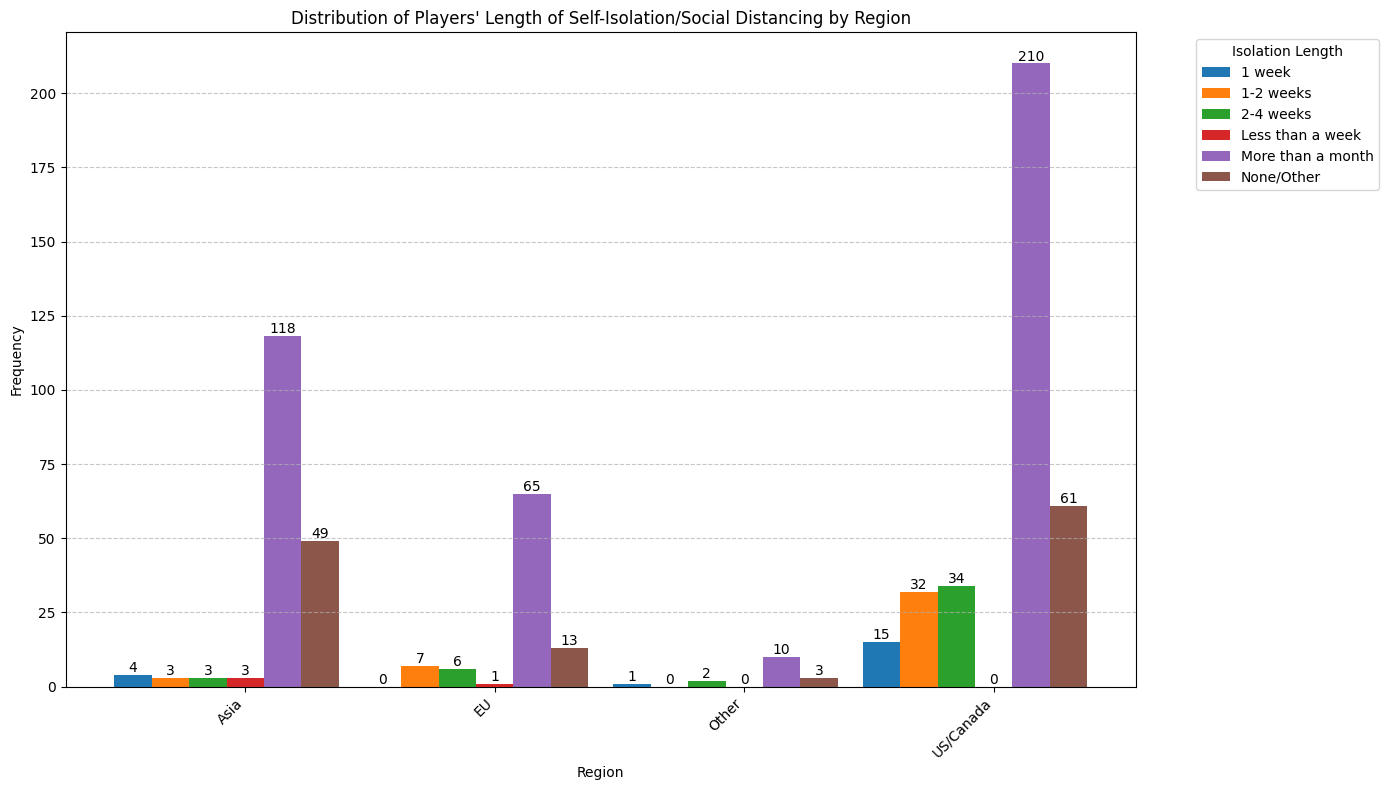

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the file (replace 'file_path' with your actual file path if needed)
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Function to categorize responses in the "B2" column
def categorize_duration(value):
    value = str(value).lower()
    if "day" in value or "week" in value or "month" in value:
        if "less" in value or "1 day" in value or "a day" in value:
            return "Less than a week"
        elif "1 week" in value or "a week" in value:
            return "1 week"
        elif "2 weeks" in value or "a couple" in value:
            return "1-2 weeks"
        elif "3 weeks" in value or "4 weeks" in value:
            return "2-4 weeks"
        elif "month" in value:
            return "More than a month"
    return "None/Other"

# Apply categorization to the "B2" column
if 'B2' in data.columns:
    data['Isolation_Category'] = data['B2'].dropna().apply(categorize_duration)
else:
    raise ValueError("Column 'B2' not found in the dataset.")

# Check if region column exists
if 'A1_2' in data.columns:
    # Group data by region and isolation category
    region_distribution = data.groupby(['A1_2', 'Isolation_Category']).size().unstack(fill_value=0)

    # Prepare data for a grouped bar chart
    categories = region_distribution.columns
    regions = region_distribution.index
    bar_width = 0.15  # Width of each bar
    x = np.arange(len(regions))  # X positions for regions

    # Create a grouped bar chart
    plt.figure(figsize=(14, 8))
    for i, category in enumerate(categories):
        plt.bar(x + i * bar_width, region_distribution[category], width=bar_width, label=category)

    # Add labels, title, and legend
    plt.title('Distribution of Players\' Length of Self-Isolation/Social Distancing by Region')
    plt.xlabel('Region')
    plt.ylabel('Frequency')
    plt.xticks(x + bar_width * (len(categories) / 2), regions, rotation=45, ha='right')
    plt.legend(title='Isolation Length', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Enhancements: Add value labels to bars
    for i in range(len(categories)):
        for j in range(len(regions)):
            plt.text(x[j] + i * bar_width, region_distribution.iloc[j, i] + 1,
                     str(region_distribution.iloc[j, i]), ha='center')

    plt.tight_layout()
    plt.savefig('region_distribution.png', dpi=300)  # Save the plot
    plt.show()
else:
    print("Column 'Region' (A1_2) not found in the dataset.")

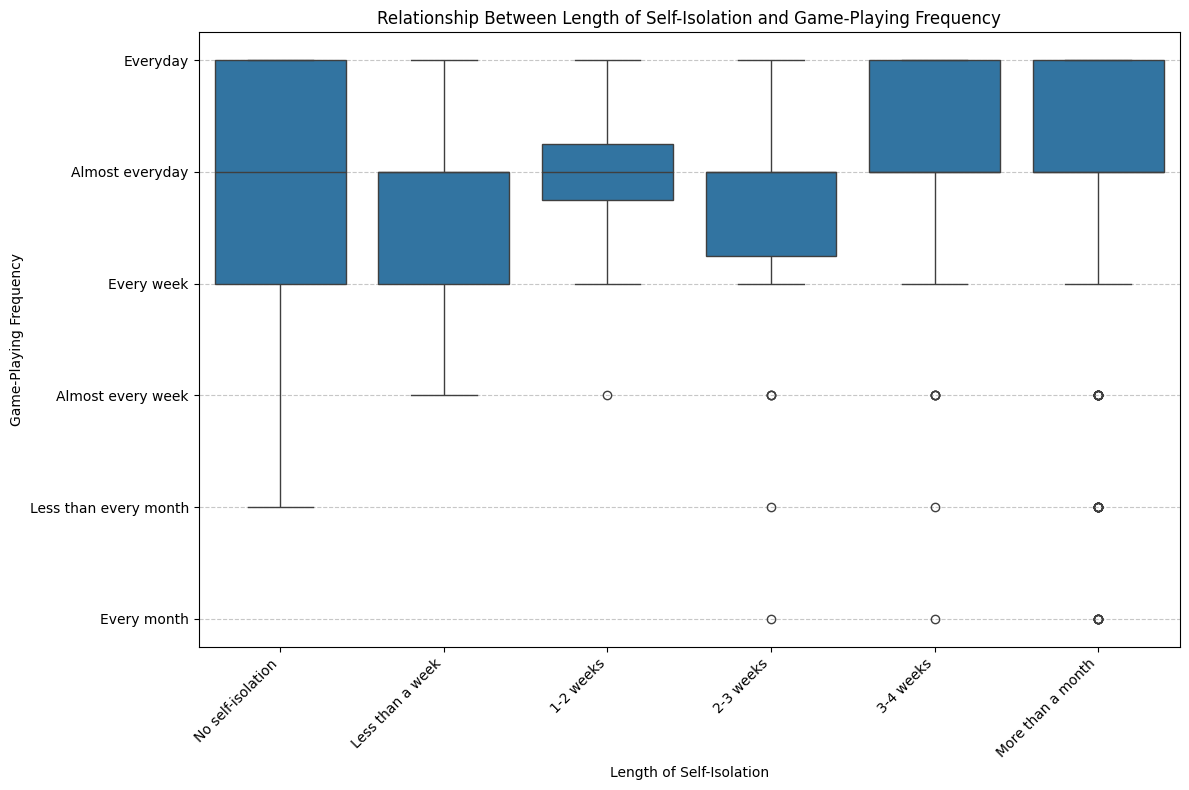

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file (replace 'file_path' with your actual file path if needed)
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Function to categorize responses in the "B2" column
def categorize_b2(value):
    value = str(value).lower()
    if "no self-isolation" in value:
        return "No self-isolation"
    elif "more than a month" in value:
        return "More than a month"
    elif "more than 3 weeks" in value:
        return "3-4 weeks"
    elif "more than 2 weeks" in value:
        return "2-3 weeks"
    elif "more than a week" in value:
        return "1-2 weeks"
    elif "day" in value or "week" in value:
        return "Less than a week"
    return "Uncategorized"

# Apply categorization to the "B2" column
if 'B2' in data.columns:
    data['B2_Category'] = data['B2'].apply(categorize_b2)
else:
    raise ValueError("Column 'B2' not found in the dataset.")

# Transform D3 (Game-Playing Frequency)
if 'D3' in data.columns:
    frequency_mapping = {
        "Everyday": 5,
        "Almost everyday": 4,
        "Every week": 3,
        "Almost every week": 2,
        "Less than every month": 1,
        "Every month": 0
    }
    reverse_frequency_mapping = {v: k for k, v in frequency_mapping.items()}
    data['D3_Numeric'] = data['D3'].map(frequency_mapping)
else:
    raise ValueError("Column 'D3' not found in the dataset.")

# Drop rows with missing transformed data
valid_data = data.dropna(subset=['B2_Category', 'D3_Numeric'])

# Potential Issues
if valid_data.empty:
    raise ValueError("No valid data available for plotting. Check 'B2' or 'D3' columns.")

# Box plot to visualize the relationship
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=valid_data,
    x='B2_Category',
    y='D3_Numeric',
    order=[
        "No self-isolation",
        "Less than a week",
        "1-2 weeks",
        "2-3 weeks",
        "3-4 weeks",
        "More than a month",
    ],
)

# Update y-axis to show labels instead of numbers
plt.yticks(
    ticks=list(reverse_frequency_mapping.keys()),
    labels=[reverse_frequency_mapping[i] for i in reverse_frequency_mapping.keys()],
)
plt.title('Relationship Between Length of Self-Isolation and Game-Playing Frequency')
plt.xlabel('Length of Self-Isolation')
plt.ylabel('Game-Playing Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Enhancements: Save plot and add annotations
plt.tight_layout()
plt.savefig('self_isolation_vs_frequency.png', dpi=300)
plt.show()

<ipython-input-7-a495cae80421>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.index, y=comparison.values, palette="viridis")


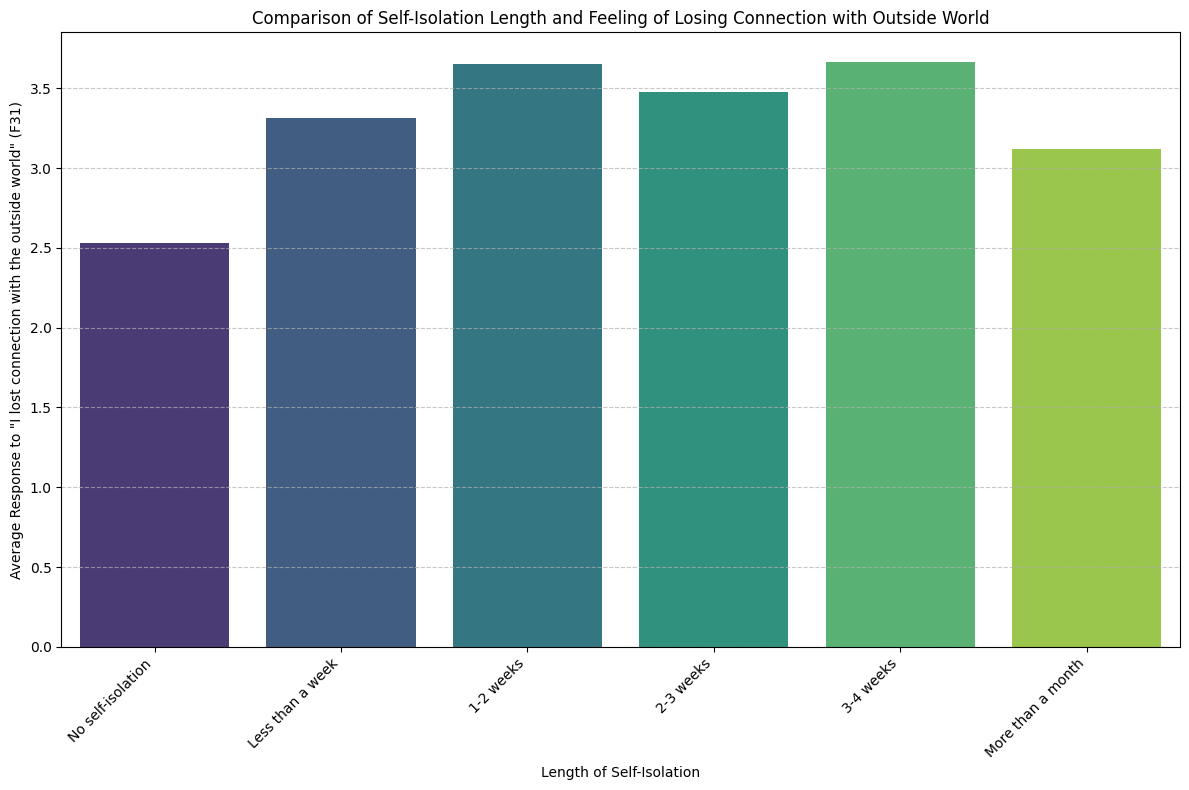

In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file (replace 'file_path' with your actual file path if needed)
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Function to categorize responses in the "B2" column
def categorize_b2(value):
    value = str(value).lower()
    if "no self-isolation" in value:
        return "No self-isolation"
    elif "more than a month" in value:
        return "More than a month"
    elif "more than 3 weeks" in value:
        return "3-4 weeks"
    elif "more than 2 weeks" in value:
        return "2-3 weeks"
    elif "more than a week" in value:
        return "1-2 weeks"
    elif "day" in value or "week" in value:
        return "Less than a week"
    return "Uncategorized"

# Apply categorization to the "B2" column
data['B2_Category'] = data['B2'].apply(categorize_b2)

# Ensure F31 column exists and contains valid data
if 'F31' in data.columns:
    # Convert F31 responses to numeric if they are on a scale (e.g., Likert scale 1-5)
    f31_numeric = pd.to_numeric(data['F31'], errors='coerce')

    # Drop rows with missing data in relevant columns
    valid_data = data.dropna(subset=['B2_Category', 'F31'])

    # Group by B2_Category and calculate mean response for F31
    comparison = valid_data.groupby('B2_Category')['F31'].mean().reindex([
        "No self-isolation",
        "Less than a week",
        "1-2 weeks",
        "2-3 weeks",
        "3-4 weeks",
        "More than a month",
    ])

    # Plot the comparison
    plt.figure(figsize=(12, 8))
    sns.barplot(x=comparison.index, y=comparison.values, palette="viridis")
    plt.title('Comparison of Self-Isolation Length and Feeling of Losing Connection with Outside World')
    plt.xlabel('Length of Self-Isolation')
    plt.ylabel('Average Response to "I lost connection with the outside world" (F31)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'F31' not found in the dataset.")


<Figure size 1200x600 with 0 Axes>

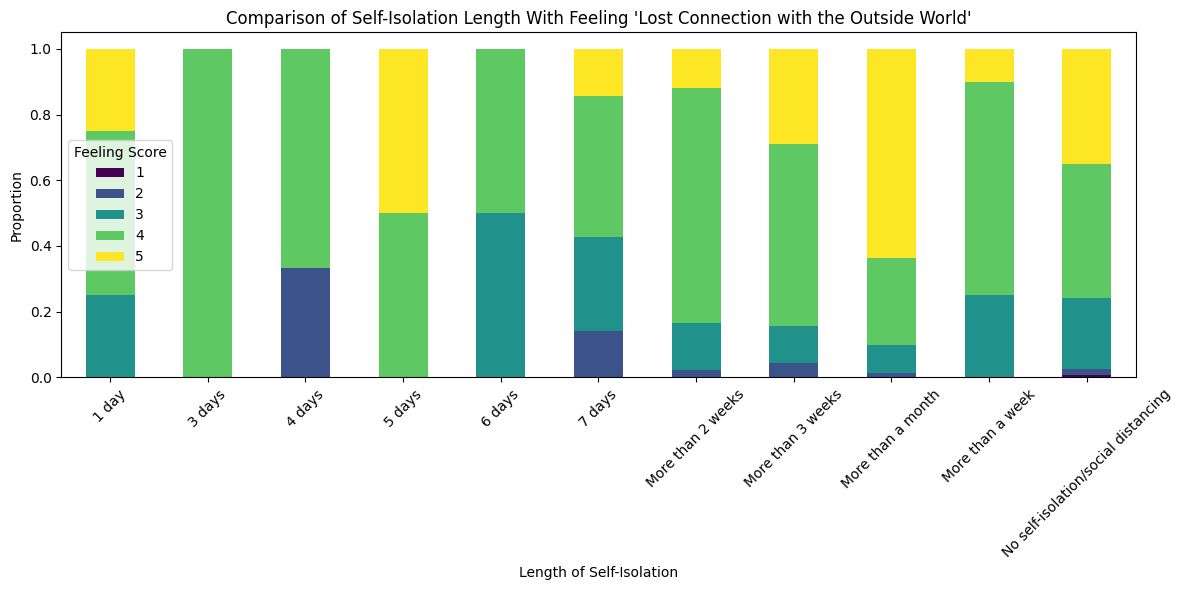

In [11]:
# Continue with your analysis
import matplotlib.pyplot as plt

# Reload the dataset if necessary
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data_csv = pd.read_csv(file_path, encoding='latin1')

# Extract relevant columns
self_isolation_length = data_csv['B2']
game_feelings = data_csv.loc[:, 'F1':'F32']

# Grouping and preparing data for analysis
# Assuming F1 corresponds to "lost connection with the outside world" for simplicity
isolation_vs_feeling = (
    data_csv.groupby('B2')['F1']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

# Plotting the comparison chart
plt.figure(figsize=(12, 6))
isolation_vs_feeling.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

# Add chart details
plt.title("Comparison of Self-Isolation Length With Feeling 'Lost Connection with the Outside World'")
plt.ylabel("Proportion")
plt.xlabel("Length of Self-Isolation")
plt.legend(title="Feeling Score")
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()




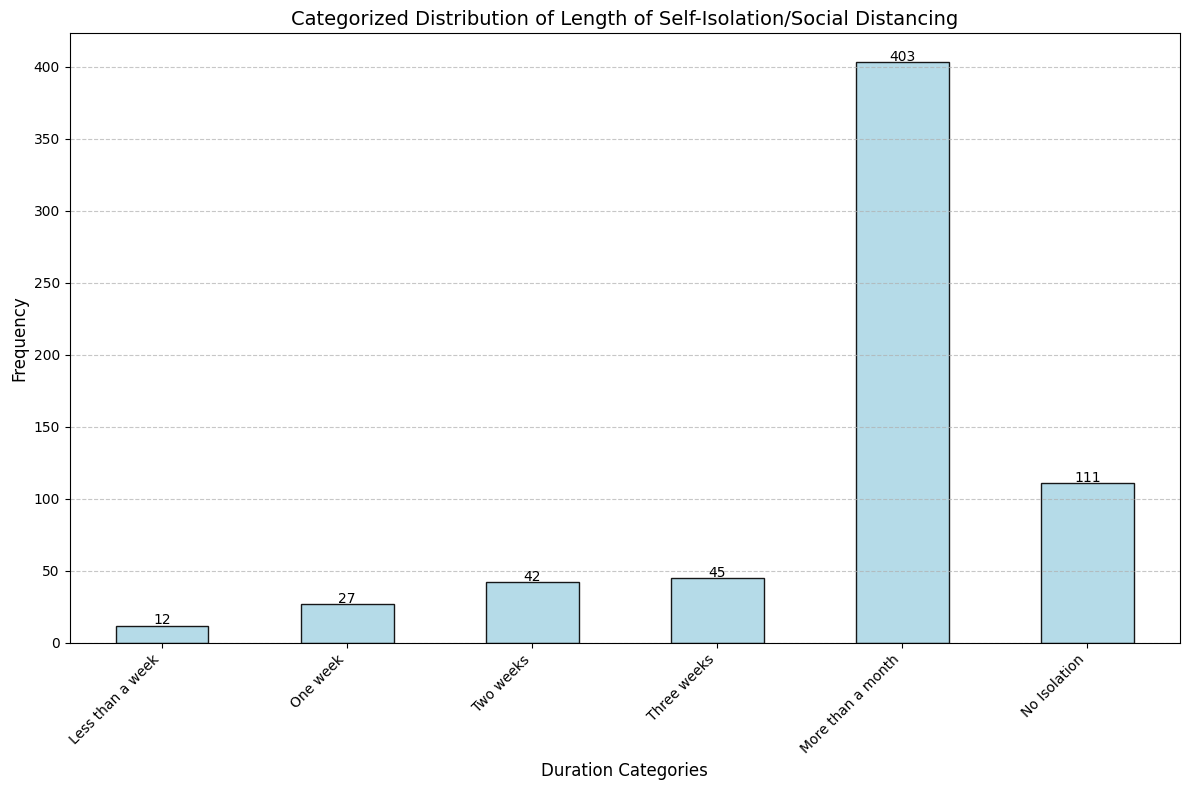

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the file (replace 'file_path' with your actual file path if needed)
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(file_path, encoding='latin1')

# Function to categorize responses in the "B2" column
def categorize_duration(value):
    value = str(value).lower().strip()
    if "no self-isolation" in value:
        return "No Isolation"
    elif "more than a month" in value or "more than 4 weeks" in value:
        return "More than a month"
    elif "3 weeks" in value or "21 days" in value:
        return "Three weeks"
    elif "2 weeks" in value or "14 days" in value:
        return "Two weeks"
    elif "1 week" in value or "7 days" in value or "more than a week" in value:
        return "One week"
    elif "day" in value or "less" in value or "6 days" in value or "5 days" in value:
        return "Less than a week"
    return "Others"

# Apply categorization to the "B2" column
if 'B2' in data.columns:
    data['B2_Category'] = data['B2'].apply(categorize_duration)
else:
    raise ValueError("Column 'B2' not found in the dataset.")

# Count occurrences in each category
b2_distribution = data['B2_Category'].value_counts()

# Reorder categories
category_order = [
    "Less than a week",
    "One week",
    "Two weeks",
    "Three weeks",
    "More than a month",
    "No Isolation",
]
b2_distribution = b2_distribution.reindex(category_order, fill_value=0)

# Check for potential issues
if b2_distribution.sum() == 0:
    raise ValueError("No data available after categorization. Check the 'B2' column for inconsistencies.")

# Plotting the categorized distribution with updated order
plt.figure(figsize=(12, 8))
b2_distribution.plot(kind='bar', color='lightblue', edgecolor='k', alpha=0.9)
plt.title('Categorized Distribution of Length of Self-Isolation/Social Distancing', fontsize=14)
plt.xlabel('Duration Categories', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels to the bars
for i, v in enumerate(b2_distribution):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.savefig('updated_distribution_grouped_self_isolation.png', dpi=300)  # Save the plot
plt.show()

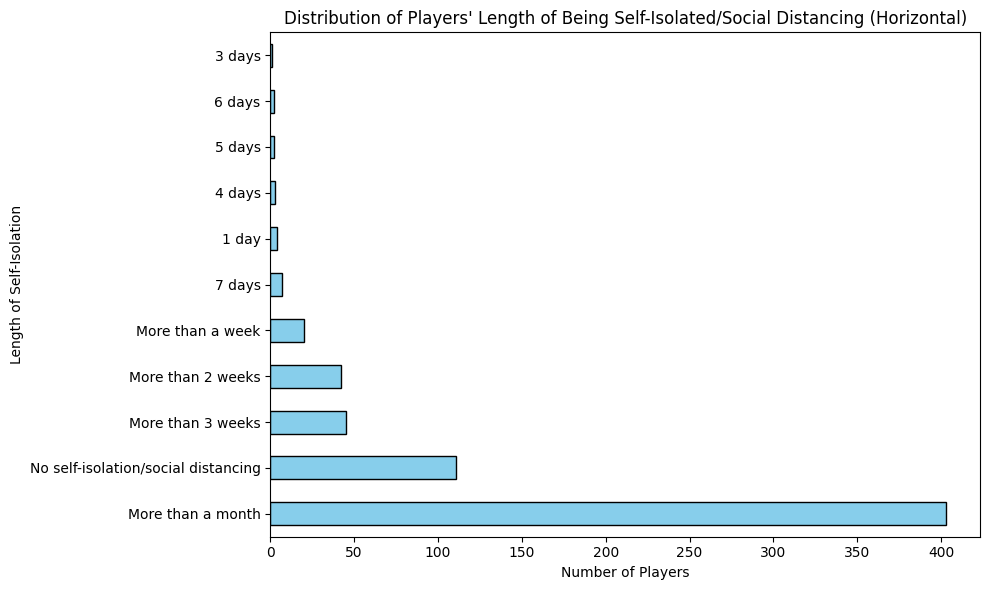

In [15]:
# Define the variable again if needed
self_isolation_distribution = data_csv['B2'].value_counts()

# Horizontal Bar Chart
plt.figure(figsize=(10, 6))
self_isolation_distribution.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title("Distribution of Players' Length of Being Self-Isolated/Social Distancing (Horizontal)")
plt.xlabel("Number of Players")
plt.ylabel("Length of Self-Isolation")
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import shap
from sklearn.model_selection import KFold

def load_data(file_path, encoding='ISO-8859-1'):
    """
    Load the dataset and return it as a DataFrame.
    """
    try:
        data = pd.read_csv(file_path, encoding=encoding)
        print(f"Data loaded successfully with shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def preprocess_data(data, behavior_columns):
    """
    Preprocess the data: scale numeric columns and handle missing values.
    """
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(data[behavior_columns]), columns=behavior_columns)
    return X

def encode_target(data, target_col):
    """
    Encode the target variable using LabelEncoder.
    """
    label_encoder = LabelEncoder()
    return label_encoder.fit_transform(data[target_col])

def calculate_mutual_info(X, y, behavior_columns):
    """
    Calculate and visualize Mutual Information scores.
    """
    mutual_info = mutual_info_classif(X, y, discrete_features=False, n_neighbors=5)
    mi_scores = pd.Series(mutual_info, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=mi_scores.values, y=mi_scores.index)
    plt.title('Feature Importance Based on Mutual Information')
    plt.xlabel('Mutual Information Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('mutual_information_importance.png')
    plt.show()
    print("Mutual Information graph saved as 'mutual_information_importance.png'.")
    return mi_scores

def calculate_random_forest_importance(X, y, behavior_columns):
    """
    Calculate and visualize feature importance using Random Forest.
    """
    model = RandomForestClassifier(random_state=42, n_jobs=-1)
    model.fit(X, y)
    feature_importances = pd.Series(model.feature_importances_, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index)
    plt.title('Feature Importance from Random Forest')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('random_forest_importance.png')
    plt.show()
    print("Random Forest graph saved as 'random_forest_importance.png'.")
    return feature_importances

def calculate_xgboost_importance(X, y, behavior_columns):
    """
    Calculate and visualize feature importance using XGBoost.
    """
    model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
    model.fit(X, y)
    feature_importances = pd.Series(model.feature_importances_, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index)
    plt.title('Feature Importance from XGBoost')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('xgboost_importance.png')
    plt.show()
    print("XGBoost graph saved as 'xgboost_importance.png'.")
    return feature_importances

def calculate_permutation_importance(model, X, y, behavior_columns):
    """
    Calculate Permutation Importance after fitting a model.
    """
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    perm_importances = pd.Series(result.importances_mean, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=perm_importances.values, y=perm_importances.index)
    plt.title('Feature Importance from Permutation')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('permutation_importance.png')
    plt.show()
    print("Permutation Importance graph saved as 'permutation_importance.png'.")
    return perm_importances

def calculate_correlation(data, target_col):
    """
    Calculate and visualize the correlation matrix.
    """
    if target_col not in data.columns:
        raise KeyError(f"{target_col} not found in the dataset.")
    corr_matrix = data.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()
    print("Correlation heatmap saved as 'correlation_heatmap.png'.")

def calculate_shap_importance(X, y):
    """
    Calculate and visualize SHAP values.
    """
    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig('shap_importance.png')
    plt.show()
    print("SHAP importance plot saved as 'shap_importance.png'.")

def evaluate_feature_stability(X, y, behavior_columns, n_splits=5):
    """
    Evaluate feature importance stability across multiple splits.
    """
    rf_importances = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_index, test_index in kf.split(X):
        model = RandomForestClassifier(random_state=42)
        model.fit(X.iloc[train_index], y[train_index])
        feature_importances = pd.Series(model.feature_importances_, index=behavior_columns)
        rf_importances.append(feature_importances)
    stability = pd.concat(rf_importances, axis=1).std(axis=1)
    plt.figure(figsize=(10, 6))
    stability.sort_values().plot(kind='barh')
    plt.title('Feature Importance Stability')
    plt.xlabel('Standard Deviation')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('feature_importance_stability.png')
    plt.show()
    print("Feature importance stability plot saved as 'feature_importance_stability.png'.")
    return stability

def aggregate_rankings(mi_scores, rf_importances, xgb_importances):
    """
    Aggregate rankings from different methods.
    """
    combined_rankings = (
        mi_scores.rank(ascending=False) +
        rf_importances.rank(ascending=False) +
        xgb_importances.rank(ascending=False)
    ) / 3
    combined_rankings = combined_rankings.sort_values()
    plt.figure(figsize=(10, 6))
    combined_rankings.plot(kind='barh')
    plt.title('Aggregated Feature Importance Rankings')
    plt.xlabel('Average Rank')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('aggregated_importance.png')
    plt.show()
    print("Aggregated feature importance plot saved as 'aggregated_importance.png'.")
    return combined_rankings

def main(data_path, target_col, behavior_prefix='E'):
    """
    Main function to execute the workflow.
    """
    data = load_data(data_path)
    if data is None:
        return

    # Extract relevant columns
    behavior_columns = [col for col in data.columns if col.startswith(behavior_prefix)]
    X = preprocess_data(data, behavior_columns)
    y = encode_target(data, target_col)

    print(f"Target variable '{target_col}' encoded successfully.")

    # Correlation Analysis
    print("Calculating Correlation Analysis...")
    calculate_correlation(data[behavior_columns + [target_col]], target_col)

    # Calculate Mutual Information
    print("Calculating Mutual Information...")
    mi_scores = calculate_mutual_info(X, y, behavior_columns)
    print(mi_scores.head())

    # Random Forest Importance
    print("Calculating Random Forest feature importance...")
    rf_importances = calculate_random_forest_importance(X, y, behavior_columns)
    print(rf_importances.head())

    # XGBoost Importance
    print("Calculating XGBoost feature importance...")
    xgb_importances = calculate_xgboost_importance(X, y, behavior_columns)
    print(xgb_importances.head())

    # Calculate Permutation Importance
    print("Calculating Permutation Importance...")
    calculate_permutation_importance(RandomForestClassifier(random_state=42).fit(X, y), X, y, behavior_columns)

    # SHAP Values
    print("Calculating SHAP values...")
    calculate_shap_importance(X, y)

    # Feature Stability
    print("Evaluating Feature Importance Stability...")
    evaluate_feature_stability(X, y, behavior_columns)

    # Aggregated Rankings
    print("Aggregating Rankings...")
    aggregate_rankings(mi_scores, rf_importances, xgb_importances)

# Execute the main function
if __name__ == "__main__":
    data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update the file path if necessary
    target_col = 'B2'  # Target variable column
    main(data_path, target_col)

Data loaded successfully with shape: (640, 96)
Target variable 'B2' encoded successfully.
Calculating Correlation Analysis...


ValueError: could not convert string to float: 'More than a month'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
